In [1]:
import pandas as pd
import numpy as np

TRANSACTION_PATH = "../data/raw/ieee-fraud-detection/train_transaction.csv"
IDENTITY_PATH = "../data/raw/ieee-fraud-detection/train_identity.csv"

transactions = pd.read_csv(TRANSACTION_PATH)
identity = pd.read_csv(IDENTITY_PATH)

print("Transaction shape:", transactions.shape)
print("Identity shape:", identity.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [2]:
transactions["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [3]:
fraud_rate = transactions["isFraud"].mean() * 100

print(f"Fraud rate: {fraud_rate:.2f}%")
print(f"Legitimate transactions: {(transactions['isFraud'] == 0).sum():,}")
print(f"Fraudulent transactions: {(transactions['isFraud'] == 1).sum():,}")

Fraud rate: 3.50%
Legitimate transactions: 569,877
Fraudulent transactions: 20,663


In [4]:
transactions.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
transactions.dtypes.value_counts()

float64    376
str         14
int64        4
Name: count, dtype: int64

In [6]:
print("Number of features:", transactions.shape[1])
print("\nFirst 30 columns:")
print(transactions.columns[:30].tolist())

Number of features: 394

First 30 columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13']


In [7]:
missing = (
    transactions.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing.head(20)

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V149     86.123717
V141     86.123717
V146     86.123717
V154     86.123717
V162     86.123717
V142     86.123717
V158     86.123717
V161     86.123717
V157     86.123717
V138     86.123717
V139     86.123717
dtype: float64

In [8]:
print("Features with >50% missing values:",
      (missing > 50).sum())

print("Features with >90% missing values:",
      (missing > 90).sum())

Features with >50% missing values: 174
Features with >90% missing values: 2


In [9]:
transactions.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [10]:
transactions.groupby("isFraud")["TransactionAmt"].median()

isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64

In [11]:
transactions.groupby("isFraud")["TransactionAmt"].mean()

isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

## Transaction Amount Distribution

Comparing transaction amounts between legitimate and fraudulent transactions.

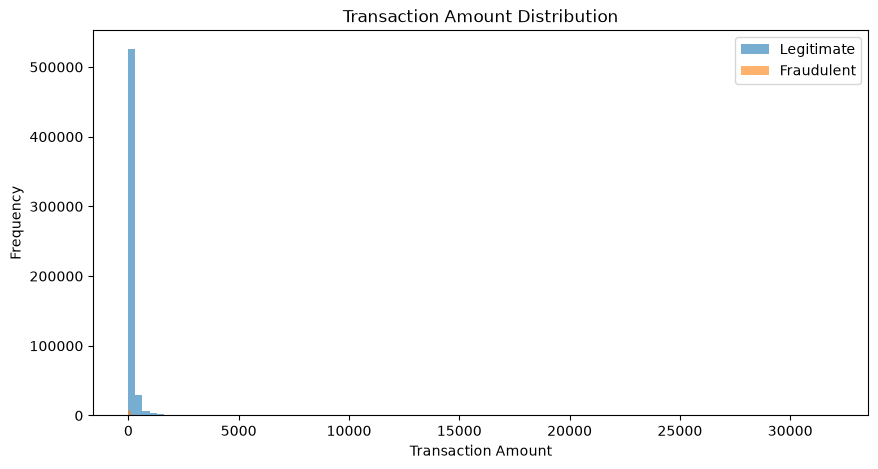

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    transactions.loc[transactions["isFraud"] == 0, "TransactionAmt"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    transactions.loc[transactions["isFraud"] == 1, "TransactionAmt"],
    bins=100,
    alpha=0.6,
    label="Fraudulent"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.legend()
plt.show()

In [14]:
transactions["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [15]:
fraud_rate = transactions["isFraud"].mean() * 100

print(f"Fraud rate: {fraud_rate:.2f}%")
print(f"Legitimate: {(transactions['isFraud'] == 0).sum():,}")
print(f"Fraudulent: {(transactions['isFraud'] == 1).sum():,}")

Fraud rate: 3.50%
Legitimate: 569,877
Fraudulent: 20,663


In [16]:
transactions.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [17]:
missing = (
    transactions.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing.head(20)

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V149     86.123717
V141     86.123717
V146     86.123717
V154     86.123717
V162     86.123717
V142     86.123717
V158     86.123717
V161     86.123717
V157     86.123717
V138     86.123717
V139     86.123717
dtype: float64

In [18]:
print("Features with >50% missing:", (missing > 50).sum())
print("Features with >90% missing:", (missing > 90).sum())

Features with >50% missing: 174
Features with >90% missing: 2


In [19]:
fraud_counts = transactions["isFraud"].value_counts()

print("Transaction counts:")
print(fraud_counts)

print("\nTransaction percentages:")
print((fraud_counts / len(transactions) * 100).round(2))

Transaction counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Transaction percentages:
isFraud
0    96.5
1     3.5
Name: count, dtype: float64


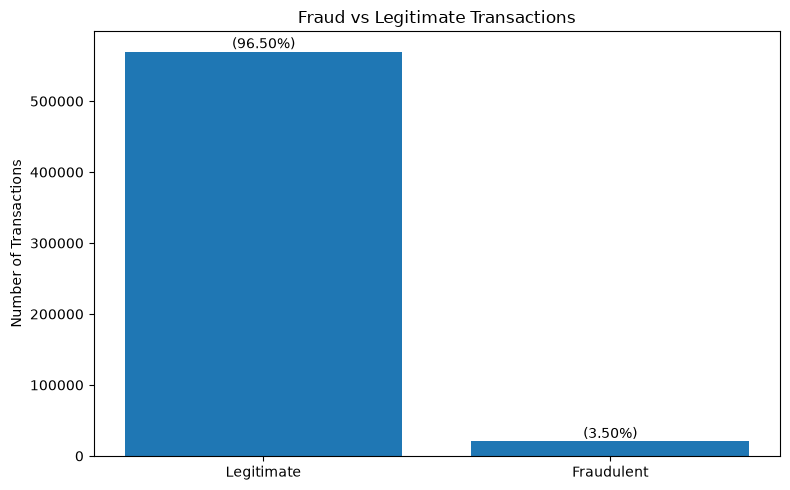

In [26]:
import matplotlib.pyplot as plt

fraud_counts = transactions["isFraud"].value_counts()

labels = ["Legitimate", "Fraudulent"]
values = [fraud_counts[0], fraud_counts[1]]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.ylabel("Number of Transactions")
plt.title("Fraud vs Legitimate Transactions")

for bar, value in zip(bars, values):
    percentage = value / len(transactions) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Key Finding

Only **3.5% of transactions are fraudulent**, creating a severe class imbalance.

This means accuracy alone would be misleading when evaluating a fraud detection model. 
Precision, recall, F1-score and PR-AUC will therefore be important evaluation metrics.

In [23]:
print("Dataset Summary")
print("-" * 30)
print(f"Total transactions : {len(transactions):,}")
print(f"Legitimate         : {fraud_counts[0]:,} (96.50%)")
print(f"Fraudulent         : {fraud_counts[1]:,} (3.50%)")
print(f"Fraud rate         : {fraud_counts[1] / len(transactions) * 100:.2f}%")

Dataset Summary
------------------------------
Total transactions : 590,540
Legitimate         : 569,877 (96.50%)
Fraudulent         : 20,663 (3.50%)
Fraud rate         : 3.50%
